In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# **Step 1: Import Libraries**

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2: Load Dataset**

In [3]:
# Load Training and Test Dataset

train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

# **Step 3: Dataset Overview**

In [4]:
# Shape of Dataset

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (891, 12)
Test Shape: (418, 11)


# **Step 4: View First 5 Rows**

In [5]:
# Display First 5 Rows

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Step 5: Understand the Dataset Columns**

In [6]:
# Display Column Names

train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# **Step 6: Dataset Information**

In [7]:
# Display Dataset Information

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **Step 7: Check Missing Values**

In [8]:
# Check Missing Values

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# **Step 8: Check Duplicate Rows**

In [9]:
# Check Duplicate Rows

duplicate_rows = train.duplicated().sum()

print("Total Duplicate Rows:", duplicate_rows)

Total Duplicate Rows: 0


# **Step 9: Check Missing Values Percentage**

In [10]:
# Check Missing Values Percentage

missing_percentage = (train.isnull().sum() / len(train)) * 100

missing_percentage.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

# **Step 10: Analyze Missing Values**

### Missing Values Analysis

- **Cabin:** 77.10% missing values
- **Age:** 19.87% missing values
- **Embarked:** 0.22% missing values

### Initial Observations

- Cabin has a very high percentage of missing values.
- Age has a moderate number of missing values.
- Embarked has only a few missing values.

# **Step 11: Drop Cabin Column**

### Why are we dropping the Cabin column?

The **Cabin** column contains **77.10% missing values** (687 out of 891 records).

Since most of the values are missing, filling them would introduce too much uncertainty.

Therefore, we will remove this column from both the training and test datasets.

In [11]:
# Drop Cabin Column

train = train.drop(columns=["Cabin"])
test = test.drop(columns=["Cabin"])

print("Cabin column removed successfully.")

Cabin column removed successfully.


# **Step 12: Check Age Distribution**

In [12]:
# Summary Statistics for Age

train["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

# **Step 13: Fill Missing Values in Age**

### Why are we using the Median?

The **Age** column has **177 missing values** (19.87%).

Since the median is less affected by outliers than the mean, we will use the **median value** to fill the missing ages.

In [13]:
# Fill Missing Values in Age

train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())

print("Missing values in Age handled successfully.")

Missing values in Age handled successfully.


# **Step 14: Handle Missing Values in Embarked**

### Why are we using the Mode?

The **Embarked** column has only **2 missing values**.

Since it is a categorical feature, we will fill the missing values with the **most frequent (mode)** category.

In [14]:
# Fill Missing Values in Embarked

train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

print("Missing values in Embarked handled successfully.")

Missing values in Embarked handled successfully.


# **Step 15: Verify Missing Values**

In [15]:
# Verify Missing Values After Data Cleaning

train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# **Step 16: Data Cleaning Summary**

## Step 16: Data Cleaning Summary

### Data Cleaning Completed Successfully

The following preprocessing steps were performed:

- Removed the **Cabin** column due to 77.10% missing values.
- Filled missing values in the **Age** column using the **median**.
- Filled missing values in the **Embarked** column using the **mode**.
- Verified that there are **no missing values** remaining in the training dataset.

The dataset is now ready for Exploratory Data Analysis (EDA).

# **Step 17: Target Variable Analysis**

In [16]:
# Check Survival Distribution

train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

# **Step 18: Visualize Target Variable**

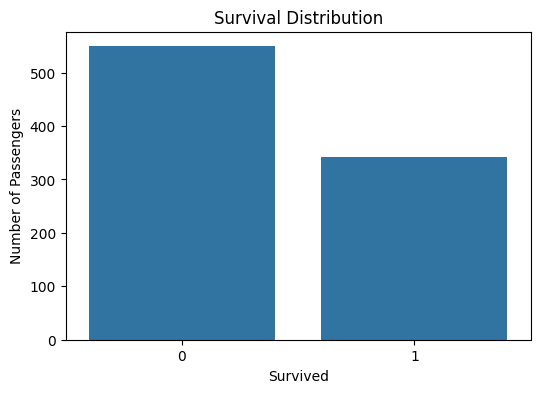

In [17]:
# Survival Count Plot

plt.figure(figsize=(6,4))

sns.countplot(data=train, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

# **Step 19: Write Insights**

## Step 19: Insights

### Observations

- The dataset contains **549 passengers who did not survive** and **342 passengers who survived**.
- More passengers died than survived in the Titanic disaster.
- The target variable is slightly imbalanced, which should be considered during model evaluation.

# **Step 20: Survival by Gender**

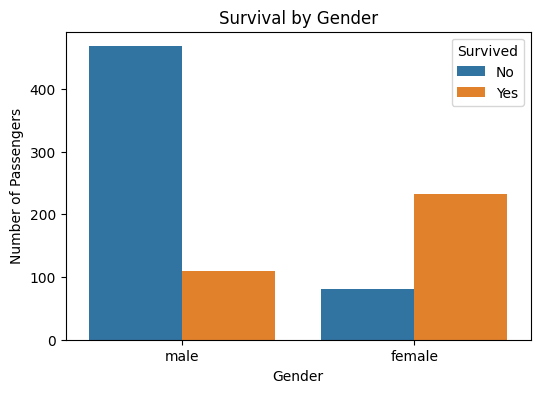

In [18]:
# Survival by Gender

plt.figure(figsize=(6,4))

sns.countplot(data=train, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

# **Step 21: Insights - Survival by Gender**

## Step 21: Insights

### Observations

- Female passengers had a much higher survival rate than male passengers.
- Most male passengers did not survive.
- A large number of female passengers survived the disaster.
- Gender appears to be one of the most important factors affecting survival.

### Business Insight

The chart suggests that **gender is a strong predictor of survival**. This feature is likely to play an important role in building a machine learning model.

# **Step 22: Survival by Passenger Class (Pclass)**

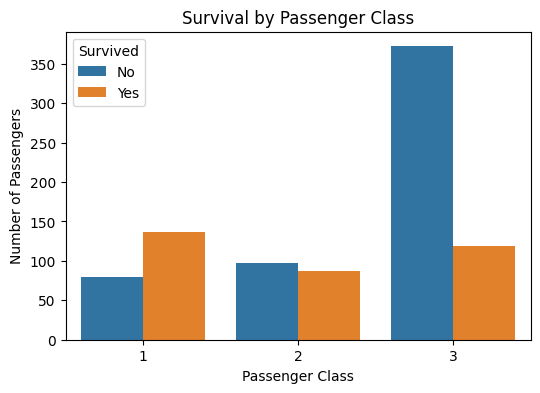

In [19]:
# Survival by Passenger Class

plt.figure(figsize=(6,4))

sns.countplot(data=train, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

# **Step 23: Insights - Survival by Passenger Class**

## Step 23: Insights

### Observations

- First Class (Pclass = 1) passengers had the highest survival rate.
- Second Class (Pclass = 2) passengers had a moderate survival rate.
- Third Class (Pclass = 3) passengers had the lowest survival rate.
- Most passengers who did not survive belonged to Third Class.

### Business Insight

Passenger Class appears to be an important feature for predicting survival. Higher-class passengers had a better chance of survival than lower-class passengers.

# **Step 24: Age Distribution**

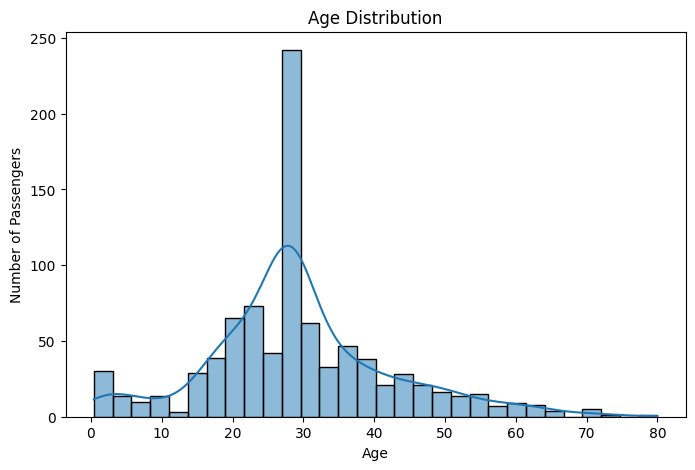

In [20]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(train["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

# **Step 25: Insights - Age Distribution**

## Step 25: Insights

### Observations

- Most passengers were between **20 and 35 years** old.
- There were fewer children and elderly passengers.
- The age distribution is **slightly right-skewed**, with a small number of older

# **Step 26: Survival by Age**

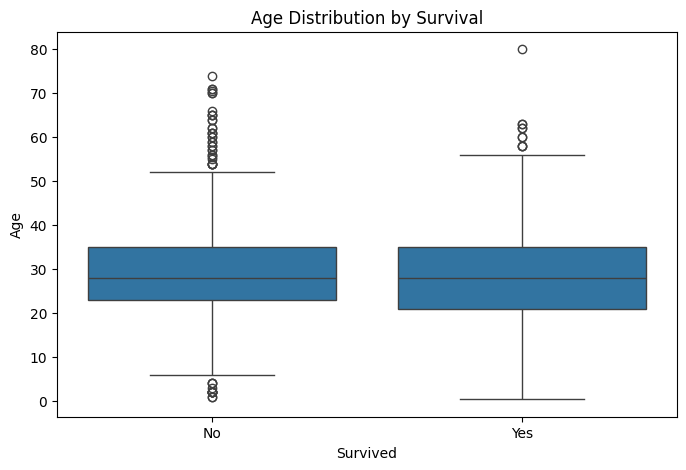

In [21]:
# Survival by Age

plt.figure(figsize=(8,5))

sns.boxplot(data=train, x="Survived", y="Age")

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.xticks([0, 1], ["No", "Yes"])

plt.show()

# **Step 27: Insights - Survival by Age**

## Step 27: Insights

### Observations

- The median age of survivors and non-survivors is quite similar.
- Both groups contain passengers of different age ranges.
- There are several outliers in both groups, including very young children and elderly passengers.
- Age alone does not clearly separate survivors from non-survivors.

### Business Insight

Age has some influence on survival, but it is not as strong as features like **Sex** and **Passenger Class**. It should still be included as a useful feature for the machine learning model.

# **Step 28: Fare Distribution**

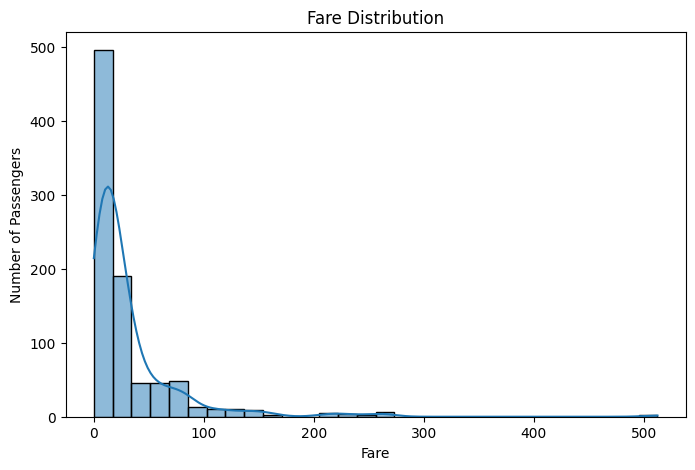

In [22]:
# Fare Distribution

plt.figure(figsize=(8,5))

sns.histplot(train["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [23]:
train["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

# **Step 29: Insights - Fare Distribution**

## Step 29: Insights

### Observations

- Most passengers paid a relatively low fare.
- The fare distribution is highly right-skewed.
- A small number of passengers paid very high ticket prices.
- The maximum fare is much higher than the median fare, indicating the presence of outliers.

### Business Insight

Fare is likely an important feature because passengers who paid higher fares may have had better access to survival opportunities. This feature should be included in the machine learning model.

# **Step 30: Survival by Fare**

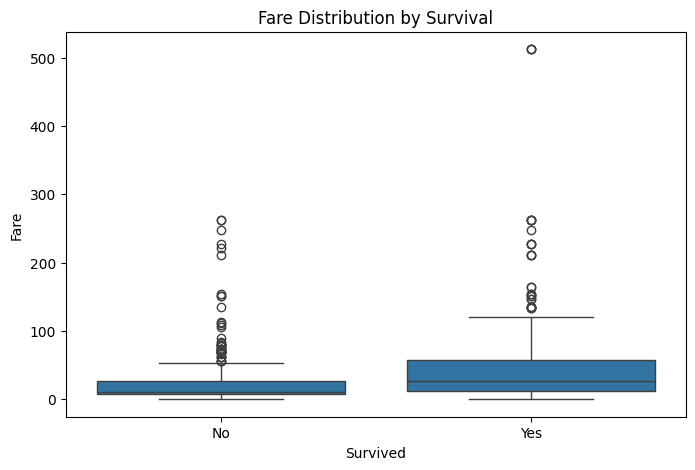

In [24]:
# Survival by Fare

plt.figure(figsize=(8,5))

sns.boxplot(data=train, x="Survived", y="Fare")

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.xticks([0, 1], ["No", "Yes"])

plt.show()

In [25]:
train.groupby("Survived")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


In [26]:
train.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

# **Step 31: Insights - Survival by Fare**

## Step 31: Insights

### Observations

- Passengers who survived paid a higher average fare than those who did not survive.
- The median fare is also higher for survivors.
- There are several high-fare outliers, especially among survivors.
- Fare appears to have a positive relationship with survival.

### Business Insight

Passengers with higher ticket fares had a better chance of survival. This may be because higher fares were associated with First Class passengers, who received better access during the evacuation.

# **Step 32: Survival by Embarked**

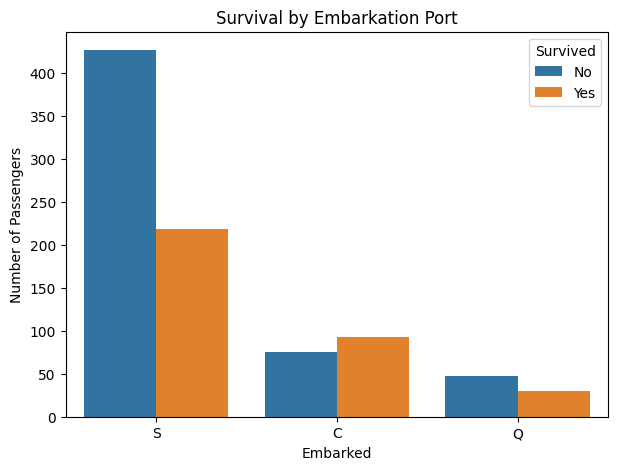

In [27]:
# Survival by Embarked

plt.figure(figsize=(7,5))

sns.countplot(data=train, x="Embarked", hue="Survived")

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

In [28]:
# Survival Summary by Embarked

train.groupby("Embarked")["Survived"].value_counts()

Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           219
Name: count, dtype: int64

In [29]:
# Survival Count by Embarked

pd.crosstab(train["Embarked"], train["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,219


In [30]:
# Survival Percentage by Embarked

pd.crosstab(
    train["Embarked"],
    train["Survived"],
    normalize="index"
) * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.099071,33.900929


In [31]:
pd.crosstab(train["Embarked"], train["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,219


In [32]:
pd.crosstab(train["Embarked"], train["Survived"], normalize="index") * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.099071,33.900929


# **Step 33: Insights - Survival by Embarked**


### Observations

- Passengers who boarded from **Cherbourg (C)** had the highest survival rate (55.36%).
- Passengers from **Southampton (S)** had the lowest

# **Step 34: Correlation Heatmap**


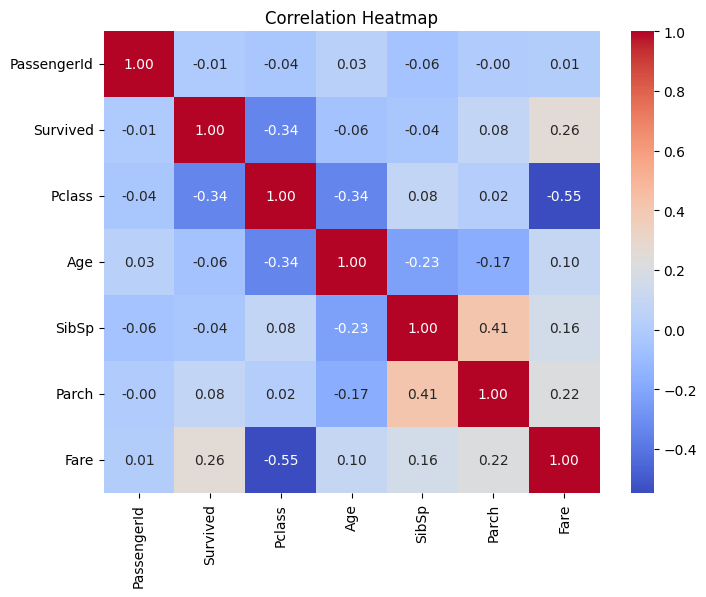

In [33]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

numeric_data = train.select_dtypes(include=["number"])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
numeric_data.corr()["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64

# **Step 35: Correlation Analysis**


### Observations

- **Passenger Class (Pclass)** has the strongest negative correlation with survival (-0.34).
- **Fare** has a positive correlation with survival (0.26), indicating that passengers who paid higher fares were more likely to survive.
- **Age** has a very weak negative correlation with survival.
- **PassengerId** has almost no relationship with survival and is not useful for prediction.
- **SibSp** and **Parch** have only weak relationships with survival.

### Business Insight

The correlation analysis confirms that **Passenger Class** and **Fare** are among the most important numerical features for predicting passenger survival. These features will be included in the machine learning model.

# **Step 36: Feature Engineering**

In [35]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

# **Step 37: Drop Unnecessary Columns**

In [36]:
# Drop Unnecessary Columns

train = train.drop(columns=["PassengerId", "Name", "Ticket"])

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# **Step 38: Encode Sex**

In [37]:
# Encode Sex Column

train["Sex"] = train["Sex"].map({
    "male": 0,
    "female": 1
})

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [38]:
train["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

# **Step 39: One-Hot Encode Embarked**

In [39]:
# One-Hot Encode Embarked

train = pd.get_dummies(train, columns=["Embarked"], drop_first=True)

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


# **Step 40: Feature Selection**

In [40]:
# Define Features (X) and Target (y)

X = train.drop("Survived", axis=1)

y = train["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 8)
Target Shape: (891,)


# **Step 41: Train-Test Split**

In [41]:
# Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (712, 8)
X_test Shape: (179, 8)
y_train Shape: (712,)
y_test Shape: (179,)


# **Step 42: Train Logistic Regression Model**

In [42]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Model

model = LogisticRegression(max_iter=1000)

# Train Model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# **Step 43: Make Predictions**

In [43]:
# Make Predictions

y_pred = model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


# **Step 44: Model Accuracy**

In [44]:
# Calculate Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.01%


# **Step 45: Confusion Matrix**

In [45]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[90 15]
 [19 55]]


# **Step 46: Classification Report**

In [46]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# **Step 47: Model Evaluation**


### Model Performance

- Accuracy: **81.01%**
- The model correctly predicted **145 out of 179** passengers.
- The model performed well in predicting passengers who did not survive.
- The overall performance is good for a baseline Logistic Regression model.

### Conclusion

The Logistic Regression model achieved a good accuracy and can be used as a baseline model for the Titanic dataset. More advanced models such as Decision Tree, Random Forest, or XGBoost may improve the prediction performance.

# **Step 48: Prepare test.csv**

In [47]:
# Check Missing Values in Test Dataset

test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

# **Step 49: Drop Unnecessary Columns**

In [48]:
# Drop Unnecessary Columns

test = test.drop(columns=["PassengerId", "Name", "Ticket"])

test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


# **Step 50: Handle Missing Values**

In [49]:
# Check Missing Values

test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        1
Embarked    0
dtype: int64

# **Step 51: Fill Missing Fare Value**

In [50]:
# Fill Missing Value in Fare

test["Fare"] = test["Fare"].fillna(test["Fare"].median())

print("Missing Fare value handled successfully.")

Missing Fare value handled successfully.


# **Step 52: Encode Sex**

In [51]:
# Encode Sex Column

test["Sex"] = test["Sex"].map({
    "male": 0,
    "female": 1
})

test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,34.5,0,0,7.8292,Q
1,3,1,47.0,1,0,7.0000,S
2,2,0,62.0,0,0,9.6875,Q
3,3,0,27.0,0,0,8.6625,S
4,3,1,22.0,1,1,12.2875,S


# **Step 53: Encode Embarked**

In [52]:
# One-Hot Encode Embarked

test = pd.get_dummies(test, columns=["Embarked"], drop_first=True)

test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,34.5,0,0,7.8292,True,False
1,3,1,47.0,1,0,7.0000,False,True
2,2,0,62.0,0,0,9.6875,True,False
3,3,0,27.0,0,0,8.6625,False,True
4,3,1,22.0,1,1,12.2875,False,True


# **Step 54: Convert Boolean to Integer**

In [53]:
# Convert Boolean Columns to Integer

test["Embarked_Q"] = test["Embarked_Q"].astype(int)
test["Embarked_S"] = test["Embarked_S"].astype(int)

test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,34.5,0,0,7.8292,1,0
1,3,1,47.0,1,0,7.0000,0,1
2,2,0,62.0,0,0,9.6875,1,0
3,3,0,27.0,0,0,8.6625,0,1
4,3,1,22.0,1,1,12.2875,0,1


# **Step 55: Verify Test Dataset**

In [54]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Sex         418 non-null    int64  
 2   Age         418 non-null    float64
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  
 5   Fare        418 non-null    float64
 6   Embarked_Q  418 non-null    int64  
 7   Embarked_S  418 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 26.3 KB


# **Step 56: Predict on Test Dataset**

In [55]:
# Predict Survival for Test Dataset

test_predictions = model.predict(test)

print("Predictions generated successfully!")

Predictions generated successfully!


# **Step 57: Create Submission File**

In [56]:
# Reload Test Dataset to Get PassengerId

test_submission = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

submission = pd.DataFrame({
    "PassengerId": test_submission["PassengerId"],
    "Survived": test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
